# Assignment 01 — Phần 2: Hệ Dự đoán Giá nhà Việt Nam 2024 (Regression)
**Giảng viên:** TS. Đinh Quế Trần (quetd@ptit.edu.vn)  
**Môn học:** Intelligent System Development — PTIT 2026  

---

## 1. Định nghĩa Hệ thống Thông minh Dự đoán Giá nhà
- **Bối cảnh:** Thị trường bất động sản Việt Nam biến động liên tục. Việc ước tính chính xác giá nhà dựa trên các thuộc tính (Tỉnh/thành, Diện tích, Số phòng ngủ, Số tầng) hỗ trợ người mua, người bán và ngân hàng định giá.
- **Bài toán ML:** Regression ($y \in \mathbb{R}^+$).
  - $x \in \mathbb{R}^6$: Tỉnh/thành, Diện tích (m²), Số phòng ngủ, Số phòng tắm, Số tầng, Loại nhà.
  - $y$: Giá nhà ước tính (tỷ đồng).

In [1]:
# ============================================================================
# KHỐI 1 — Nạp thư viện và cấu hình môi trường làm việc
# Bộ thư viện giống Phần 1: numpy/pandas để xử lý dữ liệu, matplotlib/seaborn
# để vẽ, joblib để xuất mô hình ra file .pkl cho web app dùng lại.
# ============================================================================
import os, sys, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

print("✅ Khai báo thư viện thành công!")

✅ Khai báo thư viện thành công!


## 2. Sơ đồ Hệ thống Thông minh Dự đoán Giá nhà

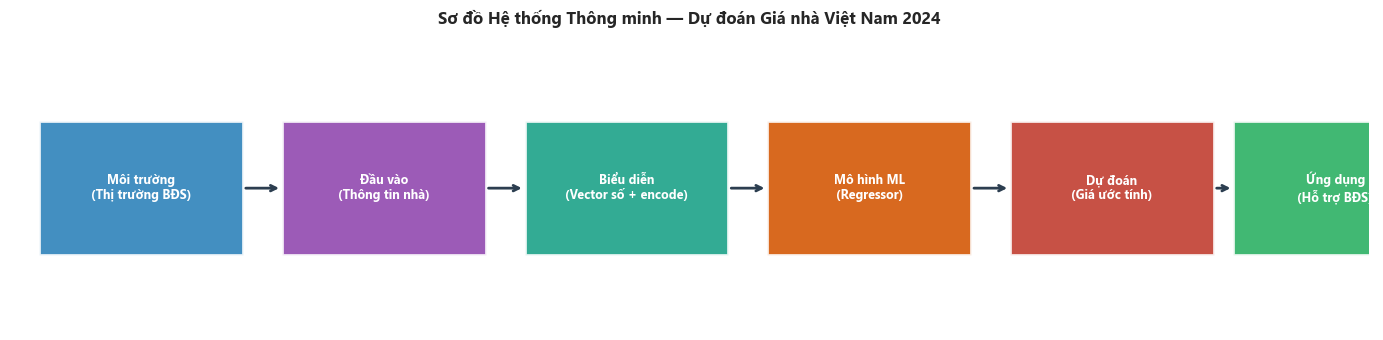

In [2]:
# ============================================================================
# KHỐI 2 — Vẽ sơ đồ kiến trúc hệ thống dự đoán giá nhà
# Sáu khối: Thị trường BĐS -> Thông tin nhà -> Biểu diễn (số + mã hoá) ->
# Mô hình hồi quy -> Giá ước tính -> Ứng dụng hỗ trợ môi giới.
# Khác Phần 1 ở chỗ đầu ra là một số thực (giá) chứ không phải nhãn 0/1.
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 3.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3.5)
ax.axis('off')

boxes = [
    (0.3, 'Môi trường\n(Thị trường BĐS)', '#2980b9'),
    (2.8, 'Đầu vào\n(Thông tin nhà)', '#8e44ad'),
    (5.3, 'Biểu diễn\n(Vector số + encode)', '#16a085'),
    (7.8, 'Mô hình ML\n(Regressor)', '#d35400'),
    (10.3, 'Dự đoán\n(Giá ước tính)', '#c0392b'),
    (12.6, 'Ứng dụng\n(Hỗ trợ BĐS)', '#27ae60'),
]

for x, label, color in boxes:
    rect = plt.Rectangle((x, 0.9), 2.1, 1.6, linewidth=2,
                          edgecolor='white', facecolor=color, alpha=0.88, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.05, 1.7, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=3)

for i in range(len(boxes) - 1):
    x_start = boxes[i][0] + 2.1
    x_end = boxes[i+1][0]
    ax.annotate('', xy=(x_end, 1.7), xytext=(x_start, 1.7),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2), zorder=4)

ax.set_title('Sơ đồ Hệ thống Thông minh — Dự đoán Giá nhà Việt Nam 2024', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('system_diagram_p2.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Quản lý & Mô phỏng Dataset Giá nhà Việt Nam 2024

In [3]:
# ============================================================================
# KHỐI 3 — Nạp hoặc sinh bộ dữ liệu bất động sản Việt Nam (2000 bản ghi)
# Nếu chưa có file local thì sinh dữ liệu mô phỏng có cấu trúc giống thị trường thật:
# diện tích theo phân phối log-normal (lệch phải), số phòng ngủ/WC/tầng theo xác suất
# cho trước, giá = giá cơ sở x hệ số tỉnh thành x hệ số loại hình x nhiễu ngẫu nhiên.
# np.random.seed(42) bảo đảm mọi lần chạy đều sinh ra đúng cùng một bộ dữ liệu.
# ============================================================================
data_path_p2 = 'data/vietnam_housing_dataset.csv'

if os.path.exists(data_path_p2):
    df2 = pd.read_csv(data_path_p2)
    print(f"✅ Đọc thành công dataset có sẵn: {df2.shape[0]} mẫu!")
else:
    np.random.seed(42)
    n = 2000
    provinces = ['Hà Nội', 'TP.HCM', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ',
                 'Bình Dương', 'Đồng Nai', 'Khánh Hòa', 'Quảng Ninh', 'Bà Rịa-VT']
    house_types = ['Nhà phố', 'Biệt thự', 'Chung cư', 'Nhà trọ', 'Đất nền']
    province_idx = np.random.choice(len(provinces), n)
    province_price_mult = [3.5, 4.0, 2.5, 2.0, 1.8, 2.2, 2.0, 2.8, 1.9, 1.7]
    area = np.random.lognormal(mean=4.5, sigma=0.6, size=n).clip(20, 500)
    bedrooms = np.random.choice([1, 2, 3, 4, 5], n, p=[0.10, 0.30, 0.35, 0.18, 0.07])
    bathrooms = np.clip(bedrooms + np.random.choice([-1, 0, 1], n), 1, 5)
    floors = np.random.choice([1, 2, 3, 4, 5], n, p=[0.30, 0.30, 0.25, 0.10, 0.05])
    house_type_idx = np.random.choice(len(house_types), n)
    house_type_mult = [1.3, 2.0, 0.9, 0.5, 0.8]
    
    base_price = (area * 0.05 + bedrooms * 0.3 + bathrooms * 0.2 + floors * 0.15)
    noise = np.random.lognormal(0, 0.2, n)
    price = (base_price
             * np.array([province_price_mult[i] for i in province_idx])
             * np.array([house_type_mult[i] for i in house_type_idx])
             * noise).clip(0.3, 200)
    
    df2 = pd.DataFrame({
        'Province': [provinces[i] for i in province_idx],
        'Area': area.round(1),
        'Bedrooms': bedrooms,
        'Bathrooms': bathrooms,
        'Floors': floors,
        'HouseType': [house_types[i] for i in house_type_idx],
        'Price': price.round(3),
    })
    df2.to_csv(data_path_p2, index=False)
    print(f"✅ Đã tạo dataset mô phỏng thành công: {n} mẫu!")

df2.head()

✅ Đọc thành công dataset có sẵn: 2000 mẫu!


,Province,Area,Bedrooms,Bathrooms,Floors,HouseType,Price
0,Đồng Nai,29.3,1,1,3,Nhà phố,6.113
1,Hải Phòng,27.5,3,3,2,Đất nền,4.713
2,Khánh Hòa,168.3,4,4,1,Chung cư,50.060
3,Cần Thơ,65.9,4,5,1,Nhà phố,15.835
4,Đồng Nai,33.5,2,3,2,Nhà phố,8.961


## 4. Biểu đồ Phân tích 1: Phân phối Giá nhà (Price Distribution)

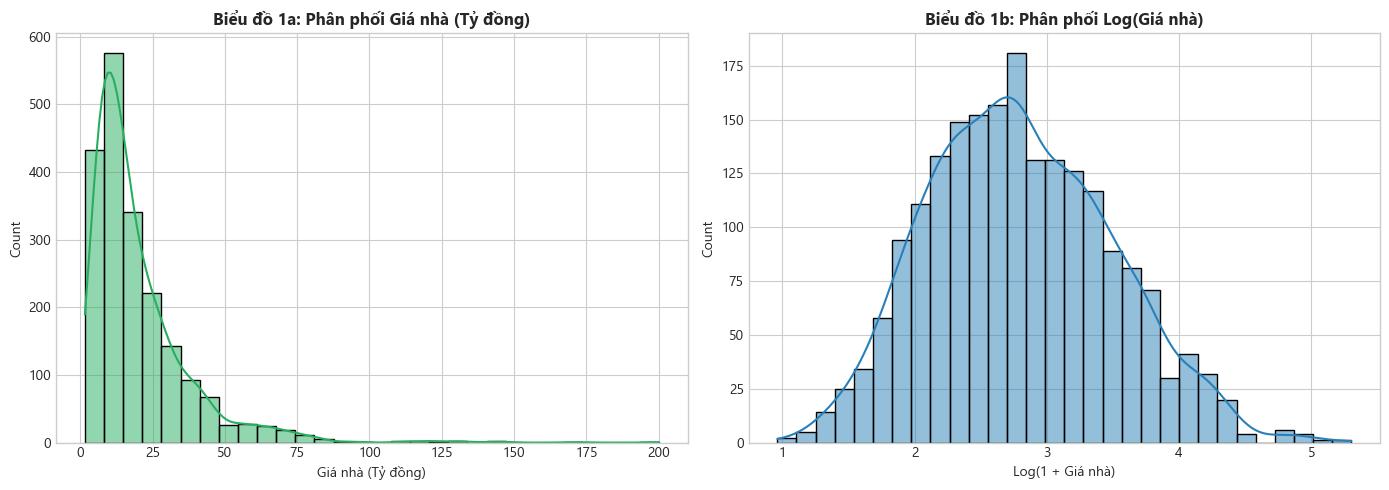

Giải thích: Giá nhà gốc có độ lệch phải (right-skewed) rõ rệt. Khi biến đổi Log, phân phối trở nên xấp xỉ phân phối chuẩn (Gaussian).


In [4]:
# ============================================================================
# KHỐI 4 — Biểu đồ 1 — phân phối giá gốc và giá sau khi lấy log
# Bên trái: giá gốc lệch phải rất mạnh (ít căn siêu đắt kéo dài đuôi phân phối).
# Bên phải: log1p(giá) đưa phân phối về gần chuẩn, giúp mô hình hồi quy học ổn định
# hơn và không bị vài căn giá cao chi phối toàn bộ hàm mất mát.
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df2['Price'], kde=True, ax=axes[0], color='#27ae60', bins=30)
axes[0].set_title('Biểu đồ 1a: Phân phối Giá nhà (Tỷ đồng)', fontweight='bold')
axes[0].set_xlabel('Giá nhà (Tỷ đồng)')

sns.histplot(np.log1p(df2['Price']), kde=True, ax=axes[1], color='#2980b9', bins=30)
axes[1].set_title('Biểu đồ 1b: Phân phối Log(Giá nhà)', fontweight='bold')
axes[1].set_xlabel('Log(1 + Giá nhà)')

plt.tight_layout()
plt.savefig('bieu_do_1_gia_nha.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Giá nhà gốc có độ lệch phải (right-skewed) rõ rệt. Khi biến đổi Log, phân phối trở nên xấp xỉ phân phối chuẩn (Gaussian).")

## 5. Biểu đồ Phân tích 2: Phân phối Diện tích & Mối tương quan với Giá

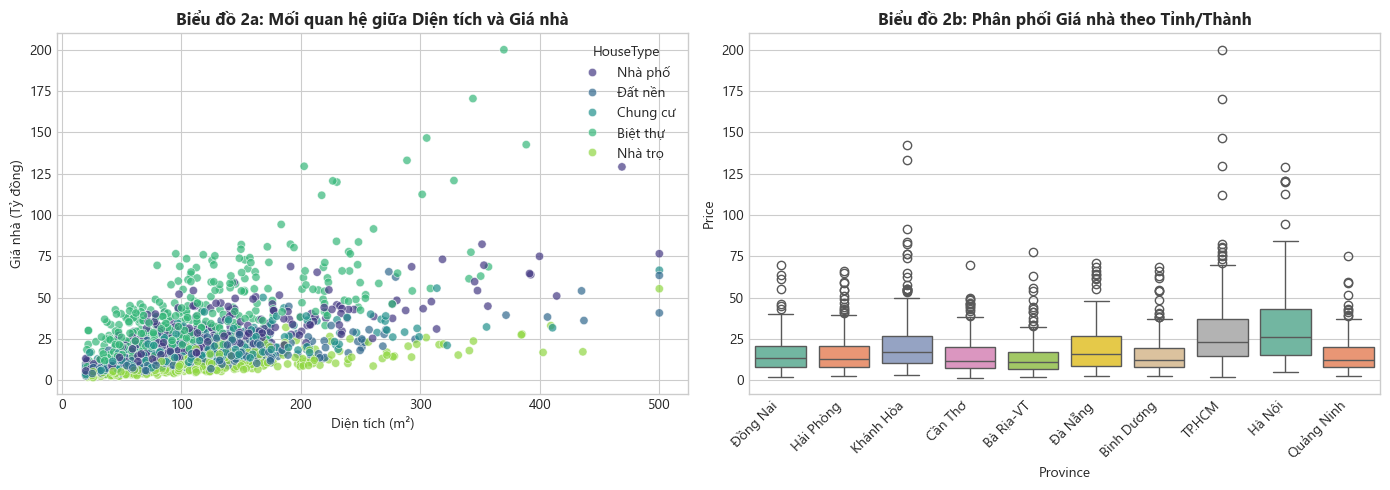

Giải thích: Diện tích càng lớn thì giá nhà càng tăng. Hà Nội và TP.HCM có mức giá cao vượt trội so với các tỉnh thành khác.


In [5]:
# ============================================================================
# KHỐI 5 — Biểu đồ 2 — quan hệ diện tích/giá và giá theo tỉnh thành
# Scatter Area–Price tô màu theo loại hình: diện tích tăng thì giá tăng, nhưng
# độ dốc khác nhau rõ rệt giữa biệt thự, nhà phố và nhà trọ.
# Boxplot theo tỉnh cho thấy Hà Nội và TP.HCM có mặt bằng giá cao vượt trội.
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df2, x='Area', y='Price', hue='HouseType', ax=axes[0], palette='viridis', alpha=0.7)
axes[0].set_title('Biểu đồ 2a: Mối quan hệ giữa Diện tích và Giá nhà', fontweight='bold')
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Giá nhà (Tỷ đồng)')

sns.boxplot(data=df2, x='Province', y='Price', ax=axes[1], palette='Set2')
axes[1].set_title('Biểu đồ 2b: Phân phối Giá nhà theo Tỉnh/Thành', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('bieu_do_2_dien_tich.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Diện tích càng lớn thì giá nhà càng tăng. Hà Nội và TP.HCM có mức giá cao vượt trội so với các tỉnh thành khác.")

## 6. Biểu đồ Phân tích 3: Ma trận Tương quan Ma trận Đặc trưng (Heatmap)

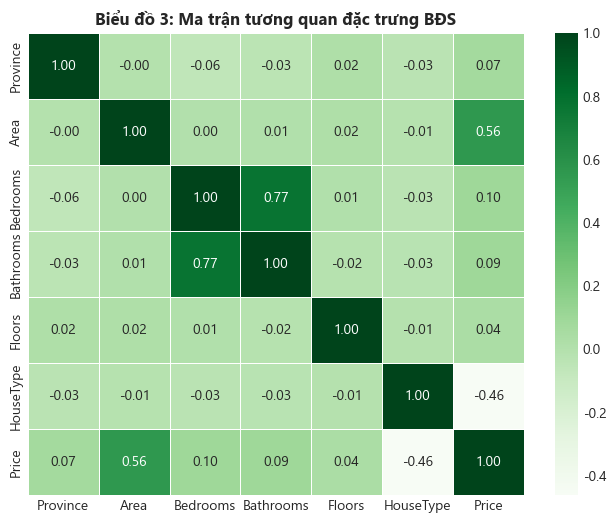

Giải thích: Diện tích (Area) và Tỉnh/thành có tương quan cao nhất với giá bất động sản.


In [6]:
# ============================================================================
# KHỐI 6 — Mã hoá biến phân loại và vẽ ma trận tương quan
# LabelEncoder chuyển Province/HouseType thành số nguyên để tính được hệ số tương quan
# và để các mô hình cây sử dụng.
# Lưu ý: cách mã hoá này áp đặt một thứ tự giả (0 < 1 < 2 ...) giữa các tỉnh, nên chỉ
# phù hợp cho mô hình cây; với mô hình tuyến tính nên dùng One-Hot Encoding.
# ============================================================================
from sklearn.preprocessing import LabelEncoder

df2_ml = df2.copy()
le_prov = LabelEncoder()
le_type = LabelEncoder()

df2_ml['Province']  = le_prov.fit_transform(df2_ml['Province'])
df2_ml['HouseType'] = le_type.fit_transform(df2_ml['HouseType'])

plt.figure(figsize=(8, 6))
sns.heatmap(df2_ml.corr(), annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Biểu đồ 3: Ma trận tương quan đặc trưng BĐS', fontweight='bold')
plt.savefig('bieu_do_3_tuong_quan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Diện tích (Area) và Tỉnh/thành có tương quan cao nhất với giá bất động sản.")

## 7-10. Huấn luyện & Đánh giá 5 Mô hình Hồi quy (Regression Models)
Sử dụng 5 độ đo tiêu chuẩn: **MAE, MSE, RMSE, R², MAPE%**.

In [7]:
# ============================================================================
# KHỐI 7 — Chia dữ liệu, chuẩn hoá và huấn luyện 5 mô hình hồi quy
# Tách đặc trưng X2 / nhãn Price, chia 80/20 (bài toán hồi quy nên không stratify).
# StandardScaler fit trên train, dùng cho các mô hình nhạy thang đo (Linear, SVR).
# Hàm mape() tự cài: sai số phần trăm trung bình, có lọc bỏ mẫu có giá bằng 0
# để tránh chia cho 0.
# Với mỗi mô hình tính đủ 5 độ đo MAE, MSE, RMSE, R² và MAPE rồi gom vào reg_df.
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = 'Price'
feature_cols_p2 = [c for c in df2_ml.columns if c != TARGET]

X2 = df2_ml[feature_cols_p2].values
y2 = df2_ml[TARGET].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

reg_models = {
    'Linear Regression':   (LinearRegression(), X2_train_s, X2_test_s),
    'Decision Tree Reg.':  (DecisionTreeRegressor(max_depth=6, random_state=42), X2_train, X2_test),
    'Random Forest Reg.':  (RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42), X2_train, X2_test),
    'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42), X2_train, X2_test),
    'SVR (RBF)':           (SVR(kernel='rbf', C=100, gamma='scale'), X2_train_s, X2_test_s),
}

reg_results = []
for name, (model, Xtr, Xte) in reg_models.items():
    model.fit(Xtr, y2_train)
    y_pred = model.predict(Xte)
    mae  = mean_absolute_error(y2_test, y_pred)
    mse  = mean_squared_error(y2_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y2_test, y_pred)
    mp   = mape(y2_test, y_pred)
    
    reg_results.append({
        'Mô hình': name, 'MAE (tỷ)': mae, 'MSE': mse, 'RMSE (tỷ)': rmse, 'R² Score': r2, 'MAPE (%)': mp
    })

reg_df = pd.DataFrame(reg_results)
reg_df

,Mô hình,MAE (tỷ),MSE,RMSE (tỷ),R² Score,MAPE (%)
0,Linear Regression,7.971085,149.173758,12.213671,0.576505,52.457541
1,Decision Tree Reg.,6.094286,96.185089,9.807400,0.726936,32.015213
2,Random Forest Reg.,4.709035,58.589481,7.654377,0.833668,24.304122
3,Gradient Boosting,4.066438,45.097208,6.715445,0.871972,20.490454
4,SVR (RBF),6.822688,113.373734,10.647710,0.678139,35.296197


## 11. Biểu đồ So sánh 5 Mô hình Hồi quy

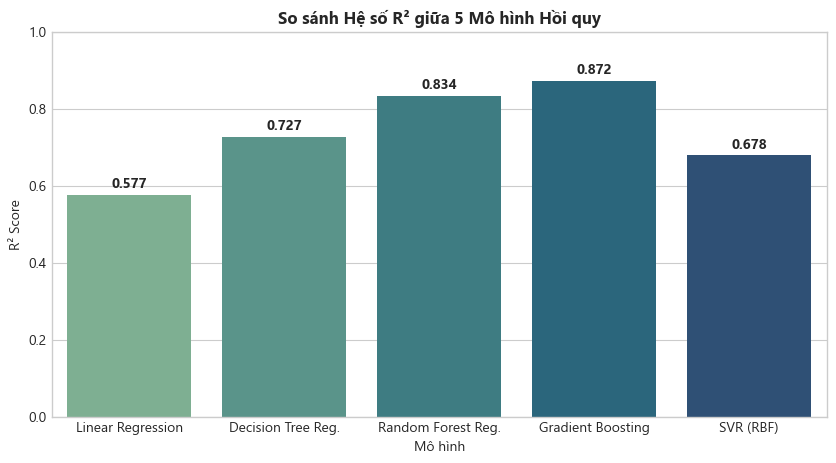

Giải thích: Gradient Boosting và Random Forest đạt kết quả R² cao nhất (R² > 0.85), giải thích được hơn 85% biến thiên của giá nhà.


In [8]:
# ============================================================================
# KHỐI 8 — Biểu đồ so sánh hệ số R² của 5 mô hình
# Barplot xếp cạnh nhau kèm nhãn số ngay trên đầu cột.
# R² cho biết mô hình giải thích được bao nhiêu phần trăm biến thiên của giá nhà;
# càng gần 1 càng tốt.
# ============================================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=reg_df, x='Mô hình', y='R² Score', palette='crest')
plt.title('So sánh Hệ số R² giữa 5 Mô hình Hồi quy', fontweight='bold')
plt.ylim(0, 1.0)
for idx, row in reg_df.iterrows():
    plt.text(idx, row['R² Score'] + 0.02, f"{row['R² Score']:.3f}", ha='center', fontweight='bold')

plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Gradient Boosting và Random Forest đạt kết quả R² cao nhất (R² > 0.85), giải thích được hơn 85% biến thiên của giá nhà.")

## 12. Lưu Mô hình & Application Demo

In [9]:
# ============================================================================
# KHỐI 9 — Lưu mô hình tốt nhất và demo dự đoán 3 bất động sản
# Xuất Gradient Boosting cùng scaler và danh sách cột ra file .pkl.
# Ba ca demo được nhập dưới dạng vector ĐÃ MÃ HOÁ (tỉnh và loại hình là số
# theo đúng bảng LabelEncoder ở trên) — phần chú thích cuối dòng ghi rõ ý nghĩa.
# Khoảng tin cậy ±15% chỉ là ước lượng minh hoạ để người dùng thấy biên độ giá.
# ============================================================================
best_model_p2 = reg_models['Gradient Boosting'][0]

joblib.dump(best_model_p2, 'model_house_price.pkl')
joblib.dump(scaler2, 'scaler_house.pkl')
joblib.dump(feature_cols_p2, 'feature_cols_p2.pkl')
print("✅ Đã xuất mô hình Gradient Boosting vào file model_house_price.pkl!")

# Test demo 3 bất động sản
demo_houses = [
    {'name': 'Nhà phố Hà Nội',   'data': [3, 80.0, 3, 2, 3, 2]},  # HN=3, 80m2, 3PN, 2WC, 3 tầng, Nhà phố=2
    {'name': 'Biệt thự TP.HCM',  'data': [7, 250.0, 5, 4, 2, 0]}, # HCM=7, 250m2, Biệt thự=0
    {'name': 'Chung cư Đà Nẵng', 'data': [8, 65.0, 2, 1, 1, 1]},  # ĐN=8, 65m2, Chung cư=1
]

print("--- DEMO DỰ ĐOÁN GIÁ 3 BẤT ĐỘNG SẢN ---")
for house in demo_houses:
    x_in = np.array([house['data']])
    pred_p = best_model_p2.predict(x_in)[0]
    print(f"📌 {house['name']}:")
    print(f"   -> Giá ước tính: {pred_p:.3f} tỷ đồng")
    print(f"   -> Khoảng giá tin cậy (±15%): [{pred_p*0.85:.3f} tỷ - {pred_p*1.15:.3f} tỷ]\n")

✅ Đã xuất mô hình Gradient Boosting vào file model_house_price.pkl!
--- DEMO DỰ ĐOÁN GIÁ 3 BẤT ĐỘNG SẢN ---
📌 Nhà phố Hà Nội:
   -> Giá ước tính: 27.643 tỷ đồng
   -> Khoảng giá tin cậy (±15%): [23.497 tỷ - 31.790 tỷ]

📌 Biệt thự TP.HCM:
   -> Giá ước tính: 102.000 tỷ đồng
   -> Khoảng giá tin cậy (±15%): [86.700 tỷ - 117.300 tỷ]

📌 Chung cư Đà Nẵng:
   -> Giá ước tính: 9.316 tỷ đồng
   -> Khoảng giá tin cậy (±15%): [7.919 tỷ - 10.714 tỷ]

